# 04 · NASNetMobile

Candidato a estudiante. 4.99M parámetros, 227 ms/imagen.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "corpus.json").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /Users/cristiansandoval/Universidad/Semillero/ButterflyModeling


In [2]:
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import tensorflow as tf

from scripts import corpus, evalStats
from scripts import modelRegistry as registro
from scripts.architectures import buildModel, descongelarCola, preprocessFn
from scripts.dataPipeline import buildAugmenter, loadSplit, preparar
from scripts.vizStyle import SERIE_1, SERIE_2, applyStyle, plotConfusionMatrix

ARQUITECTURA = "nasnet_mobile"
RUN_NAME = "nasnet-mobile"
NOTAS = "Candidato a estudiante: nasnet-mobile + cabeza comun"
ROL = "estudiante"
PROMOVER = False

# 0.0 reproduce el run con backbone congelado; 0.30 descongela la cola
FRACCION_DESCONGELADA = 0.30

TAMANO = (320, 320)
LOTE = 32
EPOCAS = 50
PACIENCIA = 8
TASA_APRENDIZAJE = 1e-4 if FRACCION_DESCONGELADA else 1e-3
SEMILLA = 42

tf.keras.utils.set_random_seed(SEMILLA)
corpus.materializar()

RUN_ID = registro.buildRunId(RUN_NAME)
RUN_DIR = registro.createRunDir(RUN_ID)
IMGS = RUN_DIR / "imgs"

print(f"run_id : {RUN_ID}")
print(f"TF     : {tf.__version__} · dispositivos: "
      f"{[d.device_type for d in tf.config.list_physical_devices()]}")

run_id : 20260906T211535Z_nasnet-mobile
TF     : 2.19.1 · dispositivos: ['CPU']


## 1 · Datos

Un tf.data.Dataset por split. Solo `train` se aumenta; `validate`/`test` son
deterministas (`shuffle=False`, indispensable para que `y_true` se alinee con
las predicciones).

In [3]:
preprocess = preprocessFn(ARQUITECTURA)
augmentador = buildAugmenter()

dsTrainCrudo, clases = loadSplit("dataset/train", TAMANO, LOTE)
dsValCrudo, _ = loadSplit("dataset/validate", TAMANO, LOTE, shuffle=False)
dsTestCrudo, _ = loadSplit("dataset/test", TAMANO, LOTE, shuffle=False)

dsTrain = preparar(dsTrainCrudo, preprocess, augmentador)
dsVal = preparar(dsValCrudo, preprocess)
dsTest = preparar(dsTestCrudo, preprocess)

print(f"{len(clases)} clases")

Found 7218 files belonging to 79 classes.
Found 1038 files belonging to 79 classes.
Found 2062 files belonging to 79 classes.
79 clases


## 2 · Modelo

In [4]:
modelo = buildModel(ARQUITECTURA, len(clases))
if FRACCION_DESCONGELADA:
    print(descongelarCola(modelo, FRACCION_DESCONGELADA))

entrenables = sum(int(np.prod(w.shape)) for w in modelo.trainable_weights)
congelados = sum(int(np.prod(w.shape)) for w in modelo.non_trainable_weights)
pd.Series({
    "parametros_totales": modelo.count_params(),
    "entrenables": entrenables,
    "congelados": congelados,
    "clases_salida": len(clases),
}).to_frame("valor")

,valor
parametros_totales,4988899
entrenables,717391
congelados,4271508
clases_salida,79


## 3 · Pesos de clase

In [5]:
pesosClase = corpus.classWeights()
pd.Series(
    {clases[i]: round(p, 3) for i, p in pesosClase.items()}
).sort_values(ascending=False).head(8).to_frame("peso")

,peso
autochton_itylus,3.151
taygetis_sylvia,3.151
cissia_confusa,3.151
pseudodebis_puritana,3.046
pyrgus_adepta,2.947
pteronymia_latilla,2.125
euselasia_mys,2.077
pteronymia_aletta,1.986


## 4 · Entrenamiento

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

modelo.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=TASA_APRENDIZAJE),
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=PACIENCIA,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3,
                       min_lr=1e-6, verbose=1),
]

inicio = datetime.now(timezone.utc)
ajuste = modelo.fit(
    dsTrain,
    validation_data=dsVal,
    epochs=EPOCAS,
    callbacks=callbacks,
    class_weight=pesosClase,
)
fin = datetime.now(timezone.utc)

historia = {k: [float(v) for v in vs] for k, vs in ajuste.history.items()}
print(f"\n{len(historia['loss'])} épocas en {(fin - inicio).total_seconds() / 60:.1f} min")

Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.0751 - loss: 4.2538 - val_accuracy: 0.1975 - val_loss: 3.2888 - learning_rate: 0.0010
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.1845 - loss: 3.2494 - val_accuracy: 0.3198 - val_loss: 2.5706 - learning_rate: 0.0010
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.2537 - loss: 2.7896 - val_accuracy: 0.3786 - val_loss: 2.2615 - learning_rate: 0.0010
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 338s 1s/step - accuracy: 0.3166 - loss: 2.5197 - val_accuracy: 0.4085 - val_loss: 2.0818 - learning_rate: 0.0010
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 337s 1s/step - accuracy: 0.3436 - loss: 2.3640 - val_accuracy: 0.4480 - val_loss: 1.9505 - learning_rate: 0.0010
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 339s 1s/step - accuracy: 0.3664 - loss: 2.2539 - val_accuracy: 0.4615 - val_loss: 1.8697 - learning_rate: 0.0010
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.3879 - loss: 2.

## 5 · Curvas de entrenamiento

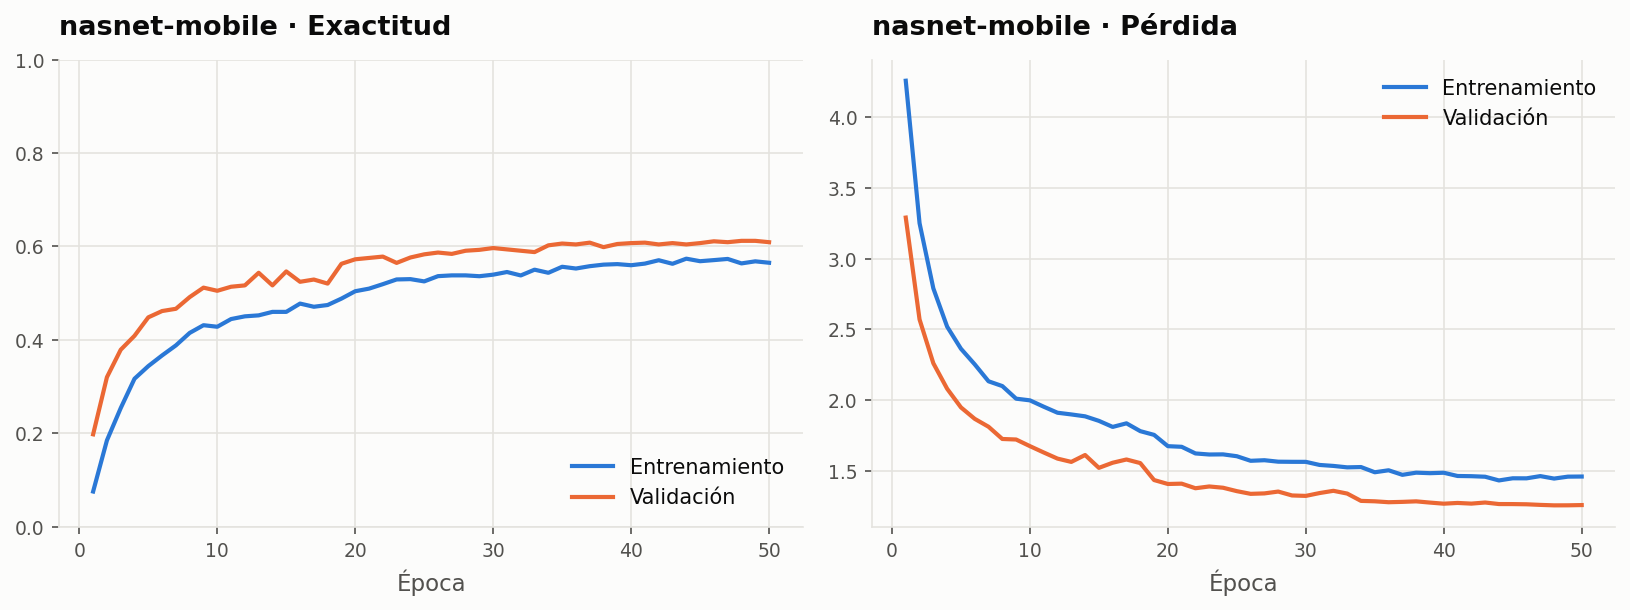

In [7]:
applyStyle()
import matplotlib.pyplot as plt

epocas = range(1, len(historia["loss"]) + 1)
figura, ejes = plt.subplots(1, 2, figsize=(11, 4.2))

ejes[0].plot(epocas, historia["accuracy"], color=SERIE_1, label="Entrenamiento")
ejes[0].plot(epocas, historia["val_accuracy"], color=SERIE_2, label="Validación")
ejes[0].set(title=f"{RUN_NAME} · Exactitud", xlabel="Época", ylim=(0, 1))
ejes[0].legend(loc="lower right")

ejes[1].plot(epocas, historia["loss"], color=SERIE_1, label="Entrenamiento")
ejes[1].plot(epocas, historia["val_loss"], color=SERIE_2, label="Validación")
ejes[1].set(title=f"{RUN_NAME} · Pérdida", xlabel="Época")
ejes[1].legend(loc="upper right")

figura.tight_layout()
figura.savefig(IMGS / "training_history.png", bbox_inches="tight")
plt.show()

## 6 · Evaluación

Dos conjuntos: `test` (20%, métrica principal) y `validate` (10%, el que
monitorean los callbacks).

In [8]:
metricas = {
    "test": evalStats.evaluar(modelo, dsTest, clases),
    "validate": evalStats.evaluar(modelo, dsVal, clases),
}

pd.DataFrame([
    {k: round(v, 4) if isinstance(v, float) else v
     for k, v in m.items()
     if k in ("num_samples", "accuracy", "top3_accuracy",
              "macro_f1", "weighted_f1", "macro_precision", "macro_recall")}
    for m in metricas.values()
], index=list(metricas.keys()))

2026-09-06 20:30:01.379621: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-09-06 20:30:34.238324: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,num_samples,accuracy,top3_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
test,2062,0.6164,0.8545,0.6147,0.6169,0.5976,0.6148
validate,1038,0.6118,0.8362,0.6195,0.6183,0.5962,0.6065


## 7 · Matriz de confusión

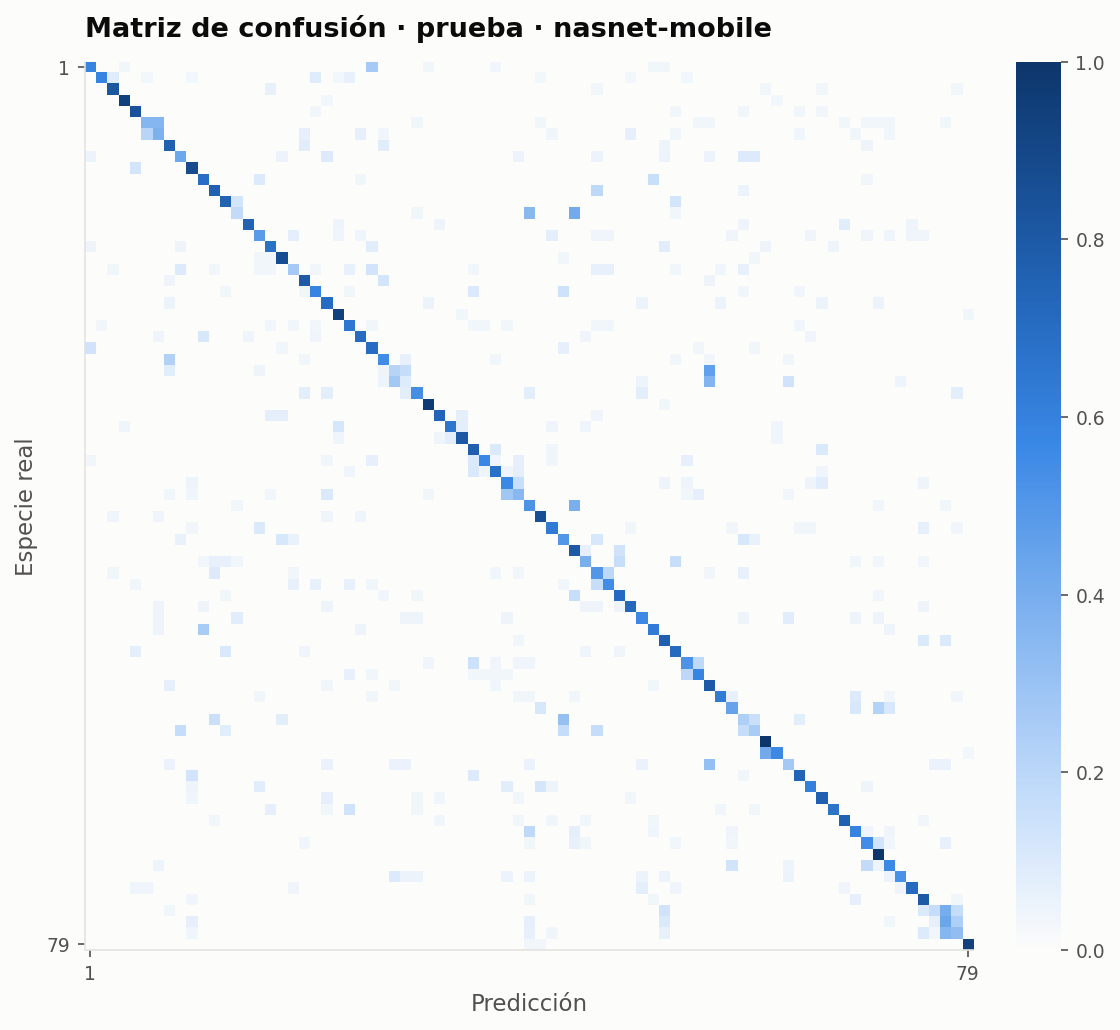

In [9]:
_ = plotConfusionMatrix(
    metricas["test"],
    f"Matriz de confusión · prueba · {RUN_NAME}",
)
plt.savefig(IMGS / "confusion_test.png", bbox_inches="tight")
plt.show()

## 8 · Confusiones principales

In [10]:
confusiones = evalStats.confusionesPrincipales(metricas["test"])
pd.DataFrame(confusiones).head(10)

,real,predicha,casos,tasa
0,pyrgus_orcus,pyrgus_adepta,14,0.412
1,cissia_pompilia,magneuptychia_alcinoe,12,0.414
2,urbanus_procne,urbanus_simplicius,12,0.400
3,hermeuptychia_hermes,magneuptychia_alcinoe,12,0.387
4,eurema_arbela,phoebis_sennae,11,0.458
5,archaeoprepona_amphimachus,archaeoprepona_demophon,11,0.355
6,urbanus_teleus,urbanus_simplicius,11,0.355
7,cissia_pompilia,hermeuptychia_hermes,10,0.345
8,eurema_xantochlora,phoebis_sennae,8,0.364
9,heliconius_melpomene,heliconius_erato,8,0.276


## 9 · Versionado

In [11]:
modelo.save(RUN_DIR / "model.keras")
registro.writeJson(RUN_DIR / "history.json", historia)
registro.writeJson(RUN_DIR / "metrics.json", {
    "run_id": RUN_ID,
    "class_names": clases,
    "splits": metricas,
    "top_confusions": {
        s: evalStats.confusionesPrincipales(m) for s, m in metricas.items()
    },
})

configuracion = {
    "run_id": RUN_ID,
    "name": RUN_NAME,
    "architecture": ARQUITECTURA,
    "role": ROL,
    "notes": NOTAS,
    "num_classes": len(clases),
    "hyperparameters": {
        "img_size": list(TAMANO),
        "batch_size": LOTE,
        "epochs_budget": EPOCAS,
        "epochs_ran": len(historia["loss"]),
        "learning_rate": TASA_APRENDIZAJE,
        "early_stopping_patience": PACIENCIA,
        "class_weights": "balanced",
        "seed": SEMILLA,
        "finetuning": FRACCION_DESCONGELADA,
        "backbone": f"{ARQUITECTURA}/imagenet",
    },
    "environment": {
        "python": platform.python_version(),
        "tensorflow": tf.__version__,
        "platform": platform.platform(),
    },
    "started_at": inicio.isoformat(),
    "finished_at": fin.isoformat(),
    "training_minutes": round((fin - inicio).total_seconds() / 60, 1),
}
registro.writeJson(RUN_DIR / "run.json", configuracion)

registro.registerRun({
    "run_id": RUN_ID,
    "name": RUN_NAME,
    "architecture": ARQUITECTURA,
    "role": ROL,
    "finetuning": FRACCION_DESCONGELADA,
    "num_classes": len(clases),
    "epochs_ran": len(historia["loss"]),
    "training_minutes": configuracion["training_minutes"],
    "test_accuracy": metricas["test"]["accuracy"],
    "test_macro_f1": metricas["test"]["macro_f1"],
    "validate_accuracy": metricas["validate"]["accuracy"],
    "validate_macro_f1": metricas["validate"]["macro_f1"],
    "notes": NOTAS,
    "created_at": inicio.isoformat(),
})

if PROMOVER:
    registro.promoteRun(RUN_ID)

print(f"Run guardado en {RUN_DIR}")

Run guardado en /Users/cristiansandoval/Universidad/Semillero/ButterflyModeling/outputs/runs/20260906T211535Z_nasnet-mobile


## Resumen

In [12]:
pd.Series({
    "run_id": RUN_ID,
    "arquitectura": ARQUITECTURA,
    "clases": len(clases),
    "epocas": len(historia["loss"]),
    "minutos": configuracion["training_minutes"],
    "test_accuracy": round(metricas["test"]["accuracy"], 4),
    "test_top3": round(metricas["test"]["top3_accuracy"], 4),
    "test_macro_f1": round(metricas["test"]["macro_f1"], 4),
    "validate_accuracy": round(metricas["validate"]["accuracy"], 4),
    "validate_macro_f1": round(metricas["validate"]["macro_f1"], 4),
}).to_frame("valor")

,valor
run_id,20260906T211535Z_nasnet-mobile
arquitectura,nasnet_mobile
clases,79
epocas,50
minutos,253.3
test_accuracy,0.6164
test_top3,0.8545
test_macro_f1,0.5976
validate_accuracy,0.6118
validate_macro_f1,0.5962
